<a href="https://www.kaggle.com/code/simarbirsinghsandhu/catboost-fe-encoding?scriptVersionId=319371016" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🏎️ F1 Pit Stop Prediction | CatBoost GPU Baseline
### Playground Series S6E5

**🏆 OOF ROC-AUC: 0.960292 | 📊 Public LB: 0.95017**

⚡ CatBoost + Optuna (GPU) | 5-Fold Stratified CV

**What's in this notebook:**
- Reconstructed `Normalized_TyreLife` — the column intentionally removed by the host
- Original dataset incorporated with domain gap flag
- Better params: `lr=0.018, depth=8, eval_metric=AUC` — trains directly on competition metric
- OOF predictions saved as `catboost_oof.csv` — ready for blending with XGBoost + RealMLP
- Feature importance visualization

> Upvote if useful 🙌 | [RealMLP](https://www.kaggle.com/code/simarbirsinghsandhu/realmlp-encoding-fe) (PB 0.95253) | [XGBoost GPU](https://www.kaggle.com/code/simarbirsinghsandhu/xgboost-gpu-fe-encoding) | [Full EDA](https://www.kaggle.com/code/simarbirsinghsandhu/s6e5-detailed-eda-original-dataset-analysis)

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import catboost as cb
import optuna
import matplotlib.pyplot as plt
import warnings

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
print(f"catboost {cb.__version__}")

catboost 1.2.10


## 2. Config

In [2]:
CONFIG = {
    "train_path"       : "/kaggle/input/competitions/playground-series-s6e5/train.csv",
    "test_path"        : "/kaggle/input/competitions/playground-series-s6e5/test.csv",
    "orig_path"        : "/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv",
    "target_col"       : "PitNextLap",
    "id_col"           : "id",
    "n_folds"          : 5,
    "seed"             : 42,
    "optuna_trials"    : 50,
    "optuna_folds"     : 3,
    "optuna_subsample" : 200_000,
}

## 3. Load Data

In [3]:
train = pd.read_csv(CONFIG["train_path"])
test  = pd.read_csv(CONFIG["test_path"])
orig  = pd.read_csv(CONFIG["orig_path"])

orig.drop(columns=["Normalized_TyreLife"], inplace=True, errors="ignore")

print(f"Train : {train.shape}")
print(f"Test  : {test.shape}")
print(f"Orig  : {orig.shape}")
print(f"\nTarget distribution:")
print(train["PitNextLap"].value_counts(normalize=True).round(4))

Train : (439140, 16)
Test  : (188165, 15)
Orig  : (101371, 15)

Target distribution:
PitNextLap
0.0    0.801
1.0    0.199
Name: proportion, dtype: float64


## 4. Feature Engineering

Same features as the XGBoost baseline — built from EDA findings.  
Key difference: `Driver`, `Compound`, `Race` passed as **categorical features** to CatBoost directly. No label encoding needed — CatBoost handles them natively with its own ordered target statistics, which is more principled than simple label encoding.

In [4]:
COMPOUND_STINT_MEDIANS = {
    "SOFT"        : 14.0,
    "MEDIUM"      : 17.0,
    "HARD"        : 23.0,
    "INTERMEDIATE": 16.0,
    "WET"         : 14.0,
}

COMPOUND_HARDNESS = {
    "SOFT"        : 1,
    "MEDIUM"      : 2,
    "HARD"        : 3,
    "INTERMEDIATE": 1,
    "WET"         : 0,
}

def engineer_features(df):
    df = df.copy()

    df["ExpectedStint"]       = df["Compound"].map(COMPOUND_STINT_MEDIANS).fillna(17.0)
    df["TyreLife_Normalized"] = df["TyreLife"] / df["ExpectedStint"]
    df["TyreLife_sq"]         = df["TyreLife"] ** 2
    df["TyreLife_sqrt"]       = np.sqrt(df["TyreLife"])
    df["TyreLife_log1p"]      = np.log1p(df["TyreLife"])
    df["Compound_Hardness"]   = df["Compound"].map(COMPOUND_HARDNESS).fillna(2).astype(int)
    df["TyreLife_x_Hardness"] = df["TyreLife"] * df["Compound_Hardness"]
    df["Norm_x_Hardness"]     = df["TyreLife_Normalized"] * df["Compound_Hardness"]
    df["Is_Fresh"]            = (df["TyreLife"] <= 3).astype(np.int8)
    df["Is_Old"]              = (df["TyreLife"] > 20).astype(np.int8)
    df["Is_VeryOld"]          = (df["TyreLife"] > 40).astype(np.int8)
    df["Is_FirstStint"]       = (df["Stint"] == 1).astype(np.int8)
    df["DegRate"]             = df["Cumulative_Degradation"] / (df["TyreLife"] + 1)
    df["Early_Race"]          = (df["RaceProgress"] < 0.25).astype(np.int8)
    df["Late_Race"]           = (df["RaceProgress"] >= 0.75).astype(np.int8)
    df["VeryLate_Race"]       = (df["RaceProgress"] >= 0.90).astype(np.int8)
    df["Is_2025"]             = (df["Year"] == 2025).astype(np.int8)

    return df

train = engineer_features(train)
test  = engineer_features(test)
orig  = engineer_features(orig)

print(f"Engineered 16 new features")

Engineered 16 new features


## 5. Preprocessing

In [5]:
CAT_COLS  = ["Driver", "Compound", "Race"]
DROP_COLS = ["id", "PitNextLap", "ExpectedStint"]

# Convert categoricals to string for CatBoost
for col in CAT_COLS:
    train[col] = train[col].astype(str)
    test[col]  = test[col].astype(str)
    orig[col]  = orig[col].astype(str)

# Domain gap flag
train["is_original"] = 0
orig["is_original"]  = 1
test["is_original"]  = 0

FEATURE_COLS = [c for c in train.columns if c not in DROP_COLS]

# Align original
orig_aligned = orig.reindex(columns=FEATURE_COLS + ["PitNextLap"], fill_value=0)
orig_aligned["PitNextLap"] = orig_aligned["PitNextLap"].astype(float)
train_full = pd.concat([train, orig_aligned], ignore_index=True)

X_df      = train_full[FEATURE_COLS]
y         = train_full["PitNextLap"].values
X_test_df = test[FEATURE_COLS]

# CatBoost needs categorical feature indices
cat_feature_indices = [X_df.columns.get_loc(c) for c in CAT_COLS]

print(f"Features         : {len(FEATURE_COLS)}")
print(f"Train rows       : {len(X_df):,}")
print(f"Positive rate    : {y.mean():.4f}")
print(f"Cat feature idx  : {cat_feature_indices}")

Features         : 31
Train rows       : 540,511
Positive rate    : 0.2094
Cat feature idx  : [0, 1, 2]


## 6. Optuna Hyperparameter Search

3-fold CV on 200K subsample, optimizing ROC-AUC directly.  
CatBoost search space differs from XGBoost — `depth`, `l2_leaf_reg`, `bagging_temperature` are the key levers.

In [6]:
def run_optuna(X_df, y, cat_indices, cfg):
    n_sub = cfg["optuna_subsample"]
    rng   = np.random.RandomState(cfg["seed"])
    idx   = rng.choice(len(X_df), min(n_sub, len(X_df)), replace=False)
    X_opt = X_df.iloc[idx].reset_index(drop=True)
    y_opt = y[idx]
    print(f"Subsampled to {len(X_opt):,} rows for Optuna")

    kf = StratifiedKFold(n_splits=cfg["optuna_folds"],
                         shuffle=True, random_state=cfg["seed"])

    def objective(trial):
        params = {
            "iterations"          : 3000,
            "learning_rate"       : trial.suggest_float("learning_rate",       0.01,  0.15, log=True),
            "depth"               : trial.suggest_int(  "depth",               4,     8),
            "l2_leaf_reg"         : trial.suggest_float("l2_leaf_reg",         1.0,   10.0, log=True),
            "bagging_temperature" : trial.suggest_float("bagging_temperature", 0.0,   1.0),
            "random_strength"     : trial.suggest_float("random_strength",     0.0,   2.0),
            "border_count"        : trial.suggest_int(  "border_count",        32,    255),
            "scale_pos_weight"    : trial.suggest_float("scale_pos_weight",    1.0,   8.0),
            "task_type"           : "GPU",
            "eval_metric"         : "AUC",
            "loss_function"       : "Logloss",
            "random_seed"         : cfg["seed"],
            "verbose"             : False,
        }

        aucs = []
        for tr_idx, va_idx in kf.split(X_opt, y_opt):
            X_tr = X_opt.iloc[tr_idx]
            X_va = X_opt.iloc[va_idx]
            y_tr = y_opt[tr_idx]
            y_va = y_opt[va_idx]

            train_pool = cb.Pool(X_tr, y_tr, cat_features=cat_indices)
            val_pool   = cb.Pool(X_va, y_va, cat_features=cat_indices)

            model = cb.CatBoostClassifier(**params)
            model.fit(train_pool,
                      eval_set=val_pool,
                      early_stopping_rounds=100,
                      verbose=False)

            aucs.append(roc_auc_score(y_va,
                        model.predict_proba(X_va)[:, 1]))
        return np.mean(aucs)

    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=cfg["seed"]))
    study.optimize(objective, n_trials=cfg["optuna_trials"], show_progress_bar=True)

    print(f"\n✅ Best ROC-AUC : {study.best_value:.6f}")
    print(f"Best params    :\n{study.best_params}")
    return study.best_params, study
    
# Uncomment to run optuna tune
# best_params, study = run_optuna(X_df, y, cat_feature_indices, CONFIG)

## 7. Best params
These are auto-filled by Optuna above. If you want to skip Optuna on re-runs, comment out the cell above and paste your best params here.

In [7]:
# best_params is already set by Optuna above
# If you skipped Optuna, uncomment and paste your params

best_params = {
    "learning_rate"      : 0.018,
    "depth"              : 8,
    "l2_leaf_reg"        : 8.5,
    "random_strength"    : 0.65,
    "bootstrap_type"     : "Bayesian",
    "bagging_temperature": 0.45,
    "auto_class_weights" : "Balanced",
    "eval_metric"        : "AUC",
}

print("Using params:", best_params)

Using params: {'learning_rate': 0.018, 'depth': 8, 'l2_leaf_reg': 8.5, 'random_strength': 0.65, 'bootstrap_type': 'Bayesian', 'bagging_temperature': 0.45, 'auto_class_weights': 'Balanced', 'eval_metric': 'AUC'}


## 8. OOF Training

Full 5-fold stratified CV. CatBoost Pool objects handle categorical features properly inside each fold.

In [8]:
def catboost_oof(X_df, y, X_test_df, cat_indices, params, cfg):
    kf         = StratifiedKFold(n_splits=cfg["n_folds"],
                                 shuffle=True, random_state=cfg["seed"])
    oof_preds  = np.zeros(len(X_df))
    test_preds = np.zeros(len(X_test_df))
    fold_aucs  = []

    run_params = {
        "iterations"          : 15000,
        "task_type"           : "GPU",
        "loss_function"       : "Logloss",
        "random_seed"         : cfg["seed"],
        "allow_writing_files" : False,
        "verbose"             : False,
        **params,
    }

    test_pool = cb.Pool(X_test_df, cat_features=cat_indices)

    for fold, (tr_idx, va_idx) in enumerate(kf.split(X_df, y)):
        X_tr = X_df.iloc[tr_idx]
        X_va = X_df.iloc[va_idx]
        y_tr = y[tr_idx]
        y_va = y[va_idx]

        train_pool = cb.Pool(X_tr, y_tr, cat_features=cat_indices)
        val_pool   = cb.Pool(X_va, y_va, cat_features=cat_indices)

        model = cb.CatBoostClassifier(**run_params)
        model.fit(train_pool,
                  eval_set=val_pool,
                  early_stopping_rounds=500,
                  verbose=500)

        val_preds         = model.predict_proba(X_va)[:, 1]
        oof_preds[va_idx] = val_preds
        test_preds       += model.predict_proba(X_test_df)[:, 1] / cfg["n_folds"]
        auc               = roc_auc_score(y_va, val_preds)
        fold_aucs.append(auc)
        print(f"Fold {fold+1} AUC: {auc:.6f}\n")

    oof_auc = roc_auc_score(y, oof_preds)
    print("─" * 45)
    for i, s in enumerate(fold_aucs):
        print(f"  Fold {i+1}: {s:.6f}")
    print("─" * 45)
    print(f"  Mean  : {np.mean(fold_aucs):.6f} ± {np.std(fold_aucs):.6f}")
    print(f"  OOF   : {oof_auc:.6f}")
    print("─" * 45)

    return oof_preds, test_preds, fold_aucs, oof_auc, model

oof_preds, test_preds, fold_aucs, oof_auc, last_model = catboost_oof(
    X_df, y, X_test_df, cat_feature_indices, best_params, CONFIG
)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8911460	best: 0.8911460 (0)	total: 12.6s	remaining: 2d 4h 19m 12s
500:	test: 0.9457782	best: 0.9457782 (500)	total: 40.5s	remaining: 19m 30s
1000:	test: 0.9518935	best: 0.9518935 (1000)	total: 1m 7s	remaining: 15m 44s
1500:	test: 0.9544612	best: 0.9544612 (1500)	total: 1m 34s	remaining: 14m 11s
2000:	test: 0.9559554	best: 0.9559554 (2000)	total: 2m 1s	remaining: 13m 10s
2500:	test: 0.9568431	best: 0.9568431 (2500)	total: 2m 28s	remaining: 12m 23s
3000:	test: 0.9575049	best: 0.9575049 (3000)	total: 2m 55s	remaining: 11m 43s
3500:	test: 0.9580467	best: 0.9580467 (3500)	total: 3m 23s	remaining: 11m 7s
4000:	test: 0.9584400	best: 0.9584403 (3998)	total: 3m 50s	remaining: 10m 34s
4500:	test: 0.9587949	best: 0.9587949 (4500)	total: 4m 18s	remaining: 10m 3s
5000:	test: 0.9590969	best: 0.9590973 (4997)	total: 4m 46s	remaining: 9m 32s
5500:	test: 0.9593312	best: 0.9593313 (5499)	total: 5m 14s	remaining: 9m 2s
6000:	test: 0.9595240	best: 0.9595240 (6000)	total: 5m 42s	remaining: 8m 33

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8997311	best: 0.8997311 (0)	total: 61.6ms	remaining: 15m 23s
500:	test: 0.9429500	best: 0.9429500 (500)	total: 27.7s	remaining: 13m 22s
1000:	test: 0.9499516	best: 0.9499516 (1000)	total: 54.8s	remaining: 12m 46s
1500:	test: 0.9526359	best: 0.9526359 (1500)	total: 1m 21s	remaining: 12m 16s
2000:	test: 0.9542617	best: 0.9542617 (2000)	total: 1m 48s	remaining: 11m 46s
2500:	test: 0.9553016	best: 0.9553016 (2500)	total: 2m 16s	remaining: 11m 20s
3000:	test: 0.9560357	best: 0.9560357 (3000)	total: 2m 43s	remaining: 10m 53s
3500:	test: 0.9565936	best: 0.9565936 (3500)	total: 3m 10s	remaining: 10m 26s
4000:	test: 0.9570217	best: 0.9570218 (3999)	total: 3m 38s	remaining: 9m 59s
4500:	test: 0.9573706	best: 0.9573706 (4500)	total: 4m 5s	remaining: 9m 33s
5000:	test: 0.9576755	best: 0.9576755 (5000)	total: 4m 33s	remaining: 9m 7s
5500:	test: 0.9579637	best: 0.9579637 (5500)	total: 5m 1s	remaining: 8m 40s
6000:	test: 0.9581625	best: 0.9581628 (5999)	total: 5m 29s	remaining: 8m 14s
6500

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8889801	best: 0.8889801 (0)	total: 54.8ms	remaining: 13m 42s
500:	test: 0.9438193	best: 0.9438193 (500)	total: 27.6s	remaining: 13m 18s
1000:	test: 0.9502915	best: 0.9502915 (1000)	total: 54.7s	remaining: 12m 45s
1500:	test: 0.9531071	best: 0.9531071 (1500)	total: 1m 21s	remaining: 12m 14s
2000:	test: 0.9546793	best: 0.9546793 (2000)	total: 1m 48s	remaining: 11m 45s
2500:	test: 0.9558215	best: 0.9558215 (2500)	total: 2m 15s	remaining: 11m 18s
3000:	test: 0.9565585	best: 0.9565585 (3000)	total: 2m 43s	remaining: 10m 52s
3500:	test: 0.9571787	best: 0.9571787 (3500)	total: 3m 10s	remaining: 10m 25s
4000:	test: 0.9576063	best: 0.9576063 (4000)	total: 3m 37s	remaining: 9m 59s
4500:	test: 0.9579737	best: 0.9579737 (4500)	total: 4m 5s	remaining: 9m 32s
5000:	test: 0.9582588	best: 0.9582588 (5000)	total: 4m 33s	remaining: 9m 6s
5500:	test: 0.9584994	best: 0.9584997 (5497)	total: 5m 1s	remaining: 8m 40s
6000:	test: 0.9587108	best: 0.9587108 (6000)	total: 5m 29s	remaining: 8m 13s
6500

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9000105	best: 0.9000105 (0)	total: 61.8ms	remaining: 15m 26s
500:	test: 0.9446070	best: 0.9446070 (500)	total: 27.8s	remaining: 13m 24s
1000:	test: 0.9512739	best: 0.9512739 (1000)	total: 54.8s	remaining: 12m 47s
1500:	test: 0.9540133	best: 0.9540133 (1500)	total: 1m 21s	remaining: 12m 14s
2000:	test: 0.9555061	best: 0.9555061 (2000)	total: 1m 48s	remaining: 11m 44s
2500:	test: 0.9564280	best: 0.9564280 (2500)	total: 2m 15s	remaining: 11m 19s
3000:	test: 0.9571547	best: 0.9571547 (3000)	total: 2m 43s	remaining: 10m 52s
3500:	test: 0.9576689	best: 0.9576689 (3500)	total: 3m 10s	remaining: 10m 26s
4000:	test: 0.9580910	best: 0.9580910 (4000)	total: 3m 38s	remaining: 9m 59s
4500:	test: 0.9584506	best: 0.9584510 (4499)	total: 4m 5s	remaining: 9m 33s
5000:	test: 0.9587395	best: 0.9587411 (4995)	total: 4m 33s	remaining: 9m 6s
5500:	test: 0.9589581	best: 0.9589581 (5500)	total: 5m 1s	remaining: 8m 40s
6000:	test: 0.9591774	best: 0.9591774 (6000)	total: 5m 29s	remaining: 8m 14s
6500

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8931982	best: 0.8931982 (0)	total: 56.4ms	remaining: 14m 5s
500:	test: 0.9460357	best: 0.9460357 (500)	total: 27.8s	remaining: 13m 23s
1000:	test: 0.9527864	best: 0.9527864 (1000)	total: 55s	remaining: 12m 49s
1500:	test: 0.9554906	best: 0.9554906 (1500)	total: 1m 22s	remaining: 12m 18s
2000:	test: 0.9569423	best: 0.9569423 (2000)	total: 1m 49s	remaining: 11m 49s
2500:	test: 0.9579597	best: 0.9579597 (2500)	total: 2m 16s	remaining: 11m 20s
3000:	test: 0.9586923	best: 0.9586923 (3000)	total: 2m 43s	remaining: 10m 54s
3500:	test: 0.9592188	best: 0.9592194 (3496)	total: 3m 11s	remaining: 10m 27s
4000:	test: 0.9596555	best: 0.9596555 (4000)	total: 3m 39s	remaining: 10m 2s
4500:	test: 0.9600058	best: 0.9600058 (4499)	total: 4m 7s	remaining: 9m 36s
5000:	test: 0.9602635	best: 0.9602635 (5000)	total: 4m 34s	remaining: 9m 9s
5500:	test: 0.9605268	best: 0.9605268 (5500)	total: 5m 3s	remaining: 8m 43s
6000:	test: 0.9607401	best: 0.9607402 (5999)	total: 5m 31s	remaining: 8m 16s
6500:	t

In [9]:
oof_df = pd.DataFrame({
    "id"        : train_full["id"].values if "id" in train_full.columns 
                  else np.arange(len(oof_preds)),
    "y_true"    : y,
    "oof_pred"  : oof_preds,
})
oof_df.to_csv("catboost_oof.csv", index=False)
print(f"✅ OOF saved → catboost_oof.csv  ({len(oof_df):,} rows)")
print(f"   OOF AUC : {oof_auc:.6f}")

✅ OOF saved → catboost_oof.csv  (540,511 rows)
   OOF AUC : 0.960619


## 9. Submission

In [10]:
submission = pd.DataFrame({
    "id"        : test["id"],
    "PitNextLap": test_preds,
})
submission.to_csv("submission.csv", index=False)

print("✅ Submission saved")
print(f"   Shape  : {submission.shape}")
print(f"   Min    : {test_preds.min():.4f}")
print(f"   Max    : {test_preds.max():.4f}")
print(f"   Mean   : {test_preds.mean():.4f}")
print(f"\n   OOF AUC: {oof_auc:.6f}")
print(submission.head())

✅ Submission saved
   Shape  : (188165, 2)
   Min    : 0.0000
   Max    : 0.9986
   Mean   : 0.2709

   OOF AUC: 0.960619
       id  PitNextLap
0  439140    0.022415
1  439141    0.021613
2  439142    0.013489
3  439143    0.294023
4  439144    0.971202


## 10. Feature Importance

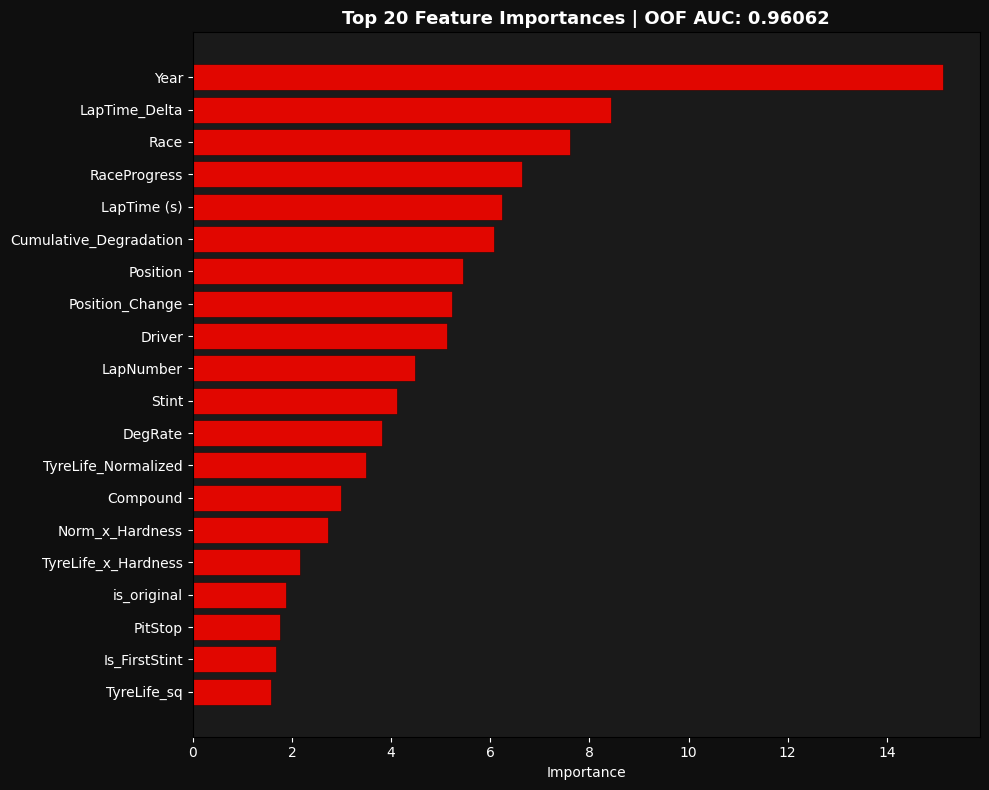

In [11]:
fi = pd.DataFrame({
    "feature"   : FEATURE_COLS,
    "importance": last_model.get_feature_importance()
}).sort_values("importance", ascending=True).tail(20)

plt.figure(figsize=(10, 8), facecolor='#0f0f0f')
plt.barh(fi["feature"], fi["importance"],
         color='#e10600', edgecolor='#0f0f0f', linewidth=0.4)
plt.title(f'Top 20 Feature Importances | OOF AUC: {oof_auc:.5f}',
          color='white', fontsize=13, fontweight='bold')
plt.xlabel('Importance', color='white')
plt.gca().set_facecolor('#1a1a1a')
plt.gca().tick_params(colors='white')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## Summary

| | Score |
|---|---|
| OOF ROC-AUC | 0.960292 |
| Public LB | 0.95017 |

**Why CatBoost complements XGBoost:**
- Native categorical handling → Driver/Race/Compound encoded more carefully
- Ordered boosting → different bias-variance tradeoff
- Different prediction errors → blending both improves LB

**Next step — blend XGBoost + CatBoost + RealMLP OOFs:**

---
*Upvote if useful 🙌 | [RealMLP](https://www.kaggle.com/code/simarbirsinghsandhu/realmlp-encoding-fe) (PB 0.95253) | [XGBoost GPU](https://www.kaggle.com/code/simarbirsinghsandhu/xgboost-gpu-fe-encoding) | [Full EDA](https://www.kaggle.com/code/simarbirsinghsandhu/s6e5-detailed-eda-original-dataset-analysis)*